In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sklearn
#!pip install prophet
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
#!pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from statsmodels.tsa.arima.model import ARIMA
#!pip install pmdarima
from pmdarima import auto_arima
from sklearn.metrics import root_mean_squared_error

C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


# Modelo de Previsão

Nesse notebook, tentaremos treinar modelos em cada CISP para prever a evolução dos casos de roubo a coletivo nos próximos anos a partir de nossa série temporal. Inicialmetne, tentaremos utilizar os modelos:
- Prophet
- XGBoost
- Arima

E comparar seus desempenhos.

## carregamento e definições

In [3]:
with open("../datasets/df_treino.pkl","rb") as file:
    df = pickle.load(file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6027 entries, 17389 to 37491
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cisp               6027 non-null   int64         
 1   mes                6027 non-null   int64         
 2   ano                6027 non-null   int64         
 3   mes_ano            6027 non-null   datetime64[ns]
 4   furto_coletivo     6027 non-null   float64       
 5   roubo_em_coletivo  6027 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 329.6 KB


Como avaliamos na análise exploratória que roubo e furtos são duas variáveis totalmente separadas, utilizaremos dois datasets e treinaremos em paralelo modelos para ambos os crimes:

In [4]:
df_furtos = df.groupby("cisp")["roubo_em_coletivo"].agg("sum").sort_values().reset_index()
#df_roubos_red = df_roubos[df_roubos["roubo_em_coletivo"]>df_roubos["roubo_em_coletivo"].median()]
#df_roubos_red = df[ df["cisp"].isin(df_roubos["cisp"])]

In [5]:
df_furtos = df.groupby("cisp")["furto_coletivo"].agg("sum").sort_values().reset_index()
#df_furtos_red = df_furtos[df_furtos["furto_coletivo"]>df_furtos["furto_coletivo"].median()]
#df_furtos_red = df[ df["cisp"].isin(df_furtos_red["cisp"])]

### Modelo Arima

Os dois modelos anteriores deram resutados pouco saisfatórios. Vamos agora tentar usar esse modelo clássico, para testar

In [6]:
tscv = TimeSeriesSplit(n_splits=5)
nums = []
divs =[]
cisps = df[["cisp", "furto_coletivo"]].sort_values(by="furto_coletivo")["cisp"].unique()
for cisp in cisps:
    print(cisp)
    df_c = (
        df[df["cisp"] == cisp]
        .sort_values("mes_ano")
        .copy()
    )
    df_c["mes_ano"] = pd.to_datetime(df_c["mes_ano"])
    df_c = df_c.set_index("mes_ano")
    df_c = df_c.asfreq("MS").fillna(0) 
    
    y = df_c["furto_coletivo"]
    for train_idx, val_idx in tscv.split(y):
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        try:
            model = auto_arima(y_train, seasonal=True, error_action='ignore')
            pred = model.predict(n_periods=len(y_val))
            nums.append(np.sum(np.abs(y_val-pred)))
            divs.append(y_val.sum())
        except Exception as e:
            # O print ajuda a saber se o erro foi de convergência ou de dados
            # print(f"Erro no CISP {cisp}: {e}")
            continue

print(np.sum(nums)/np.sum(divs))

7
11
39
43
31
23
40
22
26
42
38
33
24
30
13
20
34
14
9
37
5
44
36
18
41
19
35
15
27
28
1
25
17
12
6
4
32
29
21
10
16
0.36778541971686735


## Modelo Prophet

Iniciaremos utilizando o modelo Prophet. É um modelo bastante simples de utilizar, e teremos resultados iniciais rápidos e uma boa baseline. Iniciamos treinando o modelo para prever furtos na cisp 1::

13:10:48 - cmdstanpy - INFO - Chain [1] start processing
13:10:48 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


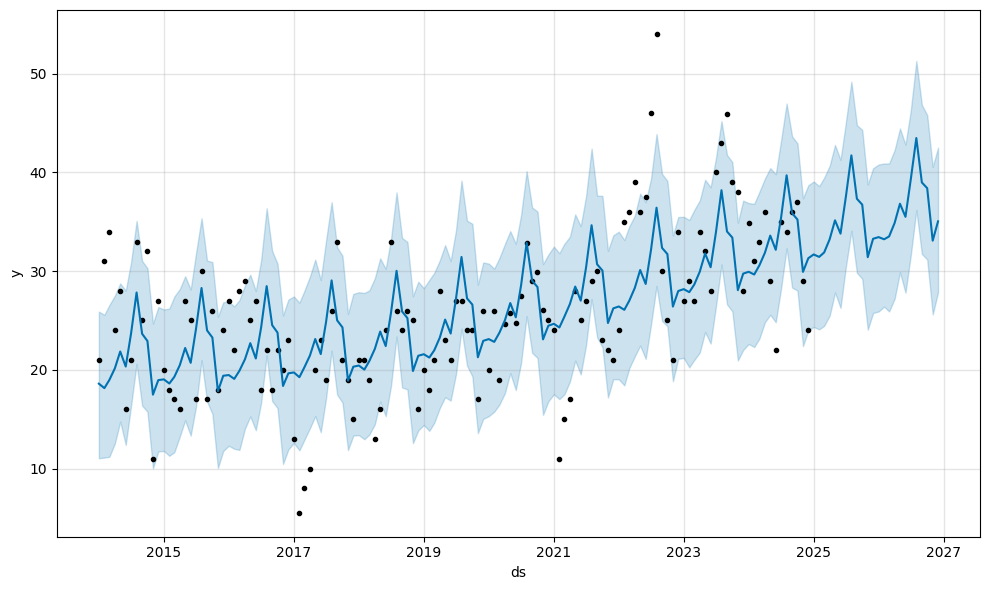

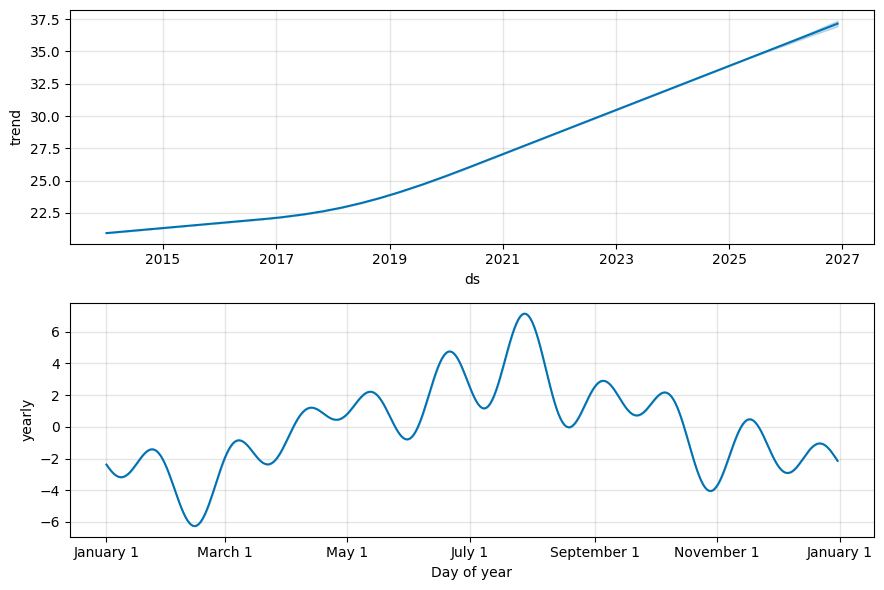

In [7]:
df_pro = df[ np.logical_and(df["cisp"] == 21, df["ano"]<=2024) ][['mes_ano', 'furto_coletivo']]
df_pro.columns = ['ds', 'y']
model = Prophet(yearly_seasonality=True, interval_width=0.8)
model.fit(df_pro)
future = model.make_future_dataframe(periods=24, freq='M')
forecast = model.predict(future)
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

Interessante. A trend parece bem clara, porém a sazonalidade parece um pouco confusa. Os intervalos de confiaça para apenas 80% são enormes, o que levanta dúvidas sobre o quão bem o modelo vai performar. Mas talvez seja uma questão de hiperparâmetros ou um ano ruim. Melhor treinar e testar o modelo pra valer. Vamos treinar o modelo em cada CISP, e o prophet já dá a função pra fazer cross-validação bem fácil. Fazendo isso posso avaliar legal a performance do modelo.

In [8]:
len(df[["cisp","furto_coletivo"]].sort_values(by="furto_coletivo")["cisp"].unique())

41

In [40]:
resultados_cv = []
nmaes_cv = []
cisps = df[["cisp","roubo_em_coletivo"]].sort_values(by="roubo_em_coletivo")["cisp"].unique()
nums = []
divs = []

for cisp in cisps:
    df_pro = df[np.logical_and(df["ano"]<2025, df["cisp"]== cisp)][['mes_ano', 'roubo_em_coletivo']]
    df_pro.columns = ['ds', 'y']
    df_pro['floor'] = 0
    df_pro['cap'] = df_pro['y'].max() * 2
    m = Prophet(
        yearly_seasonality=True,
        #growth='logistic',
        interval_width=0.8,
        changepoint_prior_scale=0.1,
        seasonality_prior_scale = 10,
    )
    m.fit(df_pro)
    df_cv = cross_validation(
        m,
        initial='1825 days',   # ~5 anos
        period='365 days',    # validação anual
        horizon='365 days'    # prever 1 ano
    )
    erro_abs_cisp = np.sum(np.abs(df_cv['y'] - df_cv['yhat']))
    real_total_cisp = np.sum(df_cv['y'])

    nums.append(erro_abs_cisp)
    divs.append(real_total_cisp)
print(np.sum(nums)/np.sum(divs))

13:45:23 - cmdstanpy - INFO - Chain [1] start processing
13:45:24 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                                                        | 0/5 [00:00<?, ?it/s]13:45:24 - cmdstanpy - INFO - Chain [1] start processing
13:45:24 - cmdstanpy - INFO - Chain [1] done processing
 20%|██████████████████████▍                                                                                         | 1/5 [00:00<00:01,  2.28it/s]13:45:25 - cmdstanpy - INFO - Chain [1] start processing
13:45:25 - cmdstanpy - INFO - Chain [1] done processing
 40%|████████████████████████████████████████████▊                                                                   | 2/5 [00:00<00:01,  2.35it/s]13:45:25 - cmdstanpy - INFO - Chain [1] start processing
13:45:25 - cmdstanpy - INFO - Chain [1] done processing
 60%|███████████████████████████████████████████████████████████████████▏                                  

0.694065676102438


O prophet teve wMAPE de 0.37. Isso indica uma acurácia de cerca de 60% em média. N

## Usando XGBoost

O prophet nos deu resultados legais para previsão, porém podemos tentar melhorar! Vamos tentar usar agora o XGBoost. É um modelo baseado em árvore, preparado para dados tabulares, e por isso vamos inicialmente precisar criar features para que ele possa operar em séries temporais.

### Features
o primeiro passo é criar um dataframe tabular pra passar pro algoritmo, pois ele não é feito para trabalhar com tempo. Criar colunas:

- mes
- ano
- n_furtos(t-1)
- n_furtos(t-3)
- n_furtos(t-12)
- media_furtos_3_meses
- media_furtos_ano
- var_furtos_3meses
- var_furtos_1ano
- furtos(t-1) - furtos(t-12)
- furtos(t-1) - furtos(t-13)
- sin, cos (mes)

E assim fazer o modelo "entender" a sazonalidade, taxa de variação e etc. Vamos criar o dataset, treinar e ver no que dá.

In [72]:
df_xg = df.copy()
df_xg = df_xg.sort_values(['cisp', 'ano', 'mes'])
g = df_xg.groupby('cisp')
# lags
df_xg['furtos_t_1'] = g['furto_coletivo'].shift(1)
df_xg['furtos_t_2'] = g['furto_coletivo'].shift(2)
df_xg['furtos_t_3'] = g['furto_coletivo'].shift(3)
df_xg['furtos_t_12'] = g['furto_coletivo'].shift(12)
df_xg['furtos_t_13'] = g['furto_coletivo'].shift(13)
df_xg['media_3m'] = (
    g['furto_coletivo']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)
df_xg['media_12m'] = ( g['furto_coletivo'].transform(lambda x: x.shift(1).rolling(12).mean()))
df_xg['var_3m'] = (g['furto_coletivo'].transform(lambda x: x.shift(1).rolling(3).var()))
df_xg['var_12m'] = (g['furto_coletivo'].transform(lambda x: x.shift(1).rolling(12).var()))
df_xg['diff_1_2'] = (df_xg['furtos_t_1'] -df_xg['furtos_t_2'])
df_xg['diff_12_13'] = (df_xg['furtos_t_12'] -df_xg['furtos_t_13'])
df_xg['mes_sin'] = np.sin(2 * np.pi * df_xg['mes'] / 12)
df_xg['mes_cos'] = np.cos(2 * np.pi * df_xg['mes'] / 12)

# remover NaNs
df_xg = df_xg.dropna().reset_index(drop=True)

In [73]:
df_xg[df_xg["cisp"]==12].max()

cisp                                  12
mes                                   12
ano                                 2026
mes_ano              2026-03-01 00:00:00
furto_coletivo                      49.0
roubo_em_coletivo               12.82918
furtos_t_1                          49.0
furtos_t_2                          49.0
furtos_t_3                          49.0
furtos_t_12                         49.0
furtos_t_13                         49.0
media_3m                       43.030242
media_12m                      37.090894
var_3m                        310.333333
var_12m                       141.405316
diff_1_2                            27.0
diff_12_13                          27.0
mes_sin                              1.0
mes_cos                              1.0
dtype: object

beleza, tenho o dataset funcionando. agora preciso treinar o modelo de fato. Vamos fazer validação cruzada com janela deslizante aqui também, e utlizar uma biblioteca para fazer o tuning dos parâmetros.

In [74]:
target = 'furto_coletivo'

features = [
    'mes', 'ano',
    'furtos_t_1', 'furtos_t_2', 'furtos_t_3','furtos_t_12', 	
    'media_3m', 'media_12m','diff_12_13',
    'var_3m', 'var_12m',
    'diff_1_2',"mes_sin","mes_cos"
]

In [75]:
tscv = TimeSeriesSplit(n_splits=5)
cisps = df[["cisp", "furto_coletivo"]].sort_values(by="furto_coletivo")["cisp"].unique()
target = 'furto_coletivo'
features = [
    'mes', 'ano',
    'furtos_t_1', 'furtos_t_2',
    'furtos_t_3', 'furtos_t_12',
    'media_3m', 'media_12m',
    'var_3m', 'var_12m',
    'diff_1_2',
    'mes_sin',
    'mes_cos',
    'diff_12_13',
]
param_dist = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'learning_rate': [
        0.005,
        0.01,
        0.03,
        0.05,
        0.1
    ],
    'max_depth': [2, 3, 4, 5, 6],
    'subsample': [
        0.6,
        0.8,
        1.0
    ],
    'colsample_bytree': [
        0.6,
        0.8,
        1.0
    ],
    'min_child_weight': [
        1,
        3,
        5,
        7
    ]
}
mae_cisps = []
nmae_cisps = []
best_params_por_cisp = {}
nums=[]
divs=[]
for cisp in cisps:
    xg_cisp = (df_xg[df_xg["cisp"] == cisp].sort_values("mes_ano"))
    X = xg_cisp[features]
    y = xg_cisp[target]
    model = XGBRegressor(objective='count:poisson',random_state=42)
    # busca aleatória
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=20,  # número de combinações testadas
        scoring='neg_mean_absolute_error',
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    random_search.fit(X, y)
    best_model = random_search.best_estimator_
    best_params_por_cisp[cisp] = (
        random_search.best_params_
    )
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        best_model.fit(X_tr, y_tr)
        pred = best_model.predict(X_val)
        nums.append(np.sum(np.abs(y_val-pred)))
        divs.append(y_val.sum())
print(np.sum(nums)/np.sum(divs))

0.3261893339874264


## Predição

Avaliando os 3 modelos, decidimos seguir com o XgBoost, que obteve os melhores resultados. Vamos agora utilizá-lo para prever crimes para os próximos 2 anos (que é a janela que usamos no treino/ cv):

In [76]:
n_meses_futuro = 24
previsoes_finais = []
for cisp in cisps:
    df_historico = df_xg[df_xg["cisp"] == cisp].sort_values("mes_ano").copy()
    params = best_params_por_cisp.get(cisp, {'objective': 'count:poisson'})
    X_train = df_historico[features]
    y_train = df_historico[target]
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    for i in range(n_meses_futuro):
        ultima_data = df_historico['mes_ano'].max()
        proxima_data = ultima_data + pd.DateOffset(months=1)
        nova_linha = pd.DataFrame(index=[0])
        nova_linha['mes_ano'] = proxima_data
        nova_linha['cisp'] = cisp
        nova_linha['mes'] = proxima_data.month
        nova_linha['ano'] = proxima_data.year
        nova_linha['furtos_t_1'] = df_historico[target].iloc[-1]
        nova_linha['furtos_t_2'] = df_historico[target].iloc[-2]
        nova_linha['furtos_t_3'] = df_historico[target].iloc[-3]
        nova_linha['furtos_t_12'] = df_historico[target].iloc[-12]
        nova_linha['media_3m'] = df_historico[target].tail(3).mean()
        nova_linha['media_12m'] = df_historico[target].tail(12).mean()
        nova_linha['var_3m'] = df_historico[target].tail(3).var()
        nova_linha['var_12m'] = df_historico[target].tail(12).var()
        nova_linha['diff_1_2'] = nova_linha['furtos_t_1'] - nova_linha['furtos_t_2']
        nova_linha['diff_12_13'] = nova_linha['furtos_t_12'] - df_historico[target].iloc[-13]
        nova_linha['mes_sin'] = np.sin(2 * np.pi * proxima_data.month / 12)
        nova_linha['mes_cos'] = np.cos(2 * np.pi * proxima_data.month / 12)
        X_pred = nova_linha[features]
        predicao = model.predict(X_pred)[0]
        nova_linha[target] = predicao
        df_historico = pd.concat([df_historico, nova_linha], ignore_index=True)
        
        previsoes_finais.append({
            'mes_ano': proxima_data,
            'cisp': cisp,
            'furto_coletivo': predicao
        })

df_futuro = pd.DataFrame(previsoes_finais)

In [77]:
df_futuro['ano'] = df_futuro['mes_ano'].dt.year
df_futuro['mes'] = df_futuro['mes_ano'].dt.month

<Axes: xlabel='mes_ano'>

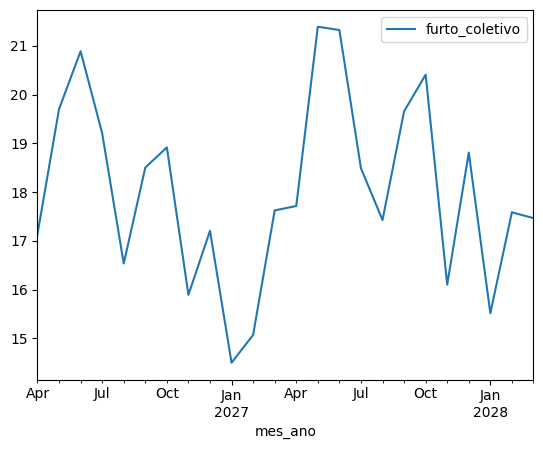

In [78]:
df_futuro[df_futuro["cisp"]==1].plot(x="mes_ano", y="furto_coletivo")

<Axes: xlabel='mes_ano'>

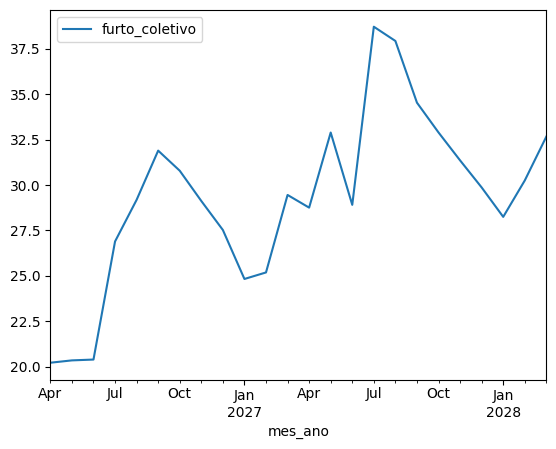

In [79]:
df_futuro[df_futuro["cisp"]==10].plot(x="mes_ano", y="furto_coletivo")

As previsões realmente parecem fazer algum sentido. Elas tem um padrão sazonal claro que o modelo captou e no segundo gráfico da pra notar que ele pegou uma tendência e queda. Só não tenho uma variância tão grande quanto nos dados reais, o padrão existe porém em muito menor escala. Mas isso me parece uma limitação razoável, se o modelo prever uma variação muito grande e ela não ocorrer ele ganha muito erro. Talvez exista alguma forma de melhorar isso, mas fica para um futuro projeto. O que resta aqui é repetir a validação e treinamento de modelos para roubos, e então completar o dataset com as previsões de futuro. Esse é o dataset que enviaremos para a solução (um dashboard), que vai exibi-lás de forma legal.
Vou apenas fazer um preguiçoso ctrl-c ctrl-v do codigo anterior, pois o tempo está acabando. Se der tempo refactor depois (:

### Modelo de Roubos

In [82]:
df_xg = df.copy()
df_xg = df_xg.sort_values(['cisp', 'ano', 'mes'])
g = df_xg.groupby('cisp')
# lags
df_xg['roubo_em_t_1'] = g['roubo_em_coletivo'].shift(1)
df_xg['roubo_em_t_2'] = g['roubo_em_coletivo'].shift(2)
df_xg['roubo_em_t_3'] = g['roubo_em_coletivo'].shift(3)
df_xg['roubo_em_t_12'] = g['roubo_em_coletivo'].shift(12)
df_xg['roubo_em_t_13'] = g['roubo_em_coletivo'].shift(13)
df_xg['media_3m'] = (g['roubo_em_coletivo'].transform(lambda x: x.shift(1).rolling(3).mean()))
df_xg['media_12m'] = ( g['roubo_em_coletivo'].transform(lambda x: x.shift(1).rolling(12).mean()))
df_xg['var_3m'] = (g['roubo_em_coletivo'].transform(lambda x: x.shift(1).rolling(3).var()))
df_xg['var_12m'] = (g['roubo_em_coletivo'].transform(lambda x: x.shift(1).rolling(12).var()))
df_xg['diff_1_2'] = (df_xg['roubo_em_t_1'] -df_xg['roubo_em_t_2'])
df_xg['diff_12_13'] = (df_xg['roubo_em_t_12'] -df_xg['roubo_em_t_13'])
df_xg['mes_sin'] = np.sin(2 * np.pi * df_xg['mes'] / 12)
df_xg['mes_cos'] = np.cos(2 * np.pi * df_xg['mes'] / 12)

# remover NaNs
df_xg = df_xg.dropna().reset_index(drop=True)

In [83]:
df_xg[df_xg["cisp"]==12].max()

cisp                                  12
mes                                   12
ano                                 2026
mes_ano              2026-03-01 00:00:00
furto_coletivo                      49.0
roubo_em_coletivo               12.82918
roubo_em_t_1                    12.82918
roubo_em_t_2                    12.82918
roubo_em_t_3                    12.82918
roubo_em_t_12                   12.82918
roubo_em_t_13                   12.82918
media_3m                        9.345526
media_12m                       6.179394
var_3m                         35.813984
var_12m                          16.0166
diff_1_2                         9.82918
diff_12_13                       9.82918
mes_sin                              1.0
mes_cos                              1.0
dtype: object

In [85]:
tscv = TimeSeriesSplit(n_splits=5)
cisps = df[["cisp", "roubo_em_coletivo"]].sort_values(by="roubo_em_coletivo")["cisp"].unique()
target = 'roubo_em_coletivo'
features = [
    'mes', 'ano',
    'roubo_em_t_1', 'roubo_em_t_2', 'roubo_em_t_3','roubo_em_t_12', 	
    'media_3m', 'media_12m','diff_12_13',
    'var_3m', 'var_12m',
    'diff_1_2',"mes_sin","mes_cos"
]
param_dist = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'learning_rate': [
        0.005,
        0.01,
        0.03,
        0.05,
        0.1
    ],
    'max_depth': [2, 3, 4, 5, 6],
    'subsample': [
        0.6,
        0.8,
        1.0
    ],
    'colsample_bytree': [
        0.6,
        0.8,
        1.0
    ],
    'min_child_weight': [
        1,
        3,
        5,
        7
    ]
}
best_params_por_cisp = {}
nums=[]
divs=[]
for cisp in cisps:
    xg_cisp = (df_xg[df_xg["cisp"] == cisp].sort_values("mes_ano"))
    X = xg_cisp[features]
    y = xg_cisp[target]
    model = XGBRegressor(objective='count:poisson',random_state=42)
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=20, 
        scoring='neg_mean_absolute_error',
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    random_search.fit(X, y)
    best_model = random_search.best_estimator_
    best_params_por_cisp[cisp] = (
        random_search.best_params_
    )
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        best_model.fit(X_tr, y_tr)
        pred = best_model.predict(X_val)
        nums.append(np.sum(np.abs(y_val-pred)))
        divs.append(y_val.sum())
print(np.sum(nums)/np.sum(divs))

0.4615461587777366


In [89]:
n_meses_futuro = 24
previsoes_finais = []
for cisp in cisps:
    df_historico = df_xg[df_xg["cisp"] == cisp].sort_values("mes_ano").copy()
    params = best_params_por_cisp.get(cisp, {'objective': 'count:poisson'})
    X_train = df_historico[features]
    y_train = df_historico[target]
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    for i in range(n_meses_futuro):
        ultima_data = df_historico['mes_ano'].max()
        proxima_data = ultima_data + pd.DateOffset(months=1)
        nova_linha = pd.DataFrame(index=[0])
        nova_linha['mes_ano'] = proxima_data
        nova_linha['cisp'] = cisp
        nova_linha['mes'] = proxima_data.month
        nova_linha['ano'] = proxima_data.year
        nova_linha['roubo_em_t_1'] = df_historico[target].iloc[-1]
        nova_linha['roubo_em_t_2'] = df_historico[target].iloc[-2]
        nova_linha['roubo_em_t_3'] = df_historico[target].iloc[-3]
        nova_linha['roubo_em_t_12'] = df_historico[target].iloc[-12]
        nova_linha['media_3m'] = df_historico[target].tail(3).mean()
        nova_linha['media_12m'] = df_historico[target].tail(12).mean()
        nova_linha['var_3m'] = df_historico[target].tail(3).var()
        nova_linha['var_12m'] = df_historico[target].tail(12).var()
        nova_linha['diff_1_2'] = nova_linha['roubo_em_t_1'] - nova_linha['roubo_em_t_2']
        nova_linha['diff_12_13'] = nova_linha['roubo_em_t_12'] - df_historico[target].iloc[-13]
        nova_linha['mes_sin'] = np.sin(2 * np.pi * proxima_data.month / 12)
        nova_linha['mes_cos'] = np.cos(2 * np.pi * proxima_data.month / 12)
        X_pred = nova_linha[features]
        predicao = model.predict(X_pred)[0]
        predicao = max(0,predicao)
        nova_linha[target] = predicao
        df_historico = pd.concat([df_historico, nova_linha], ignore_index=True)
        
        previsoes_finais.append({
            'mes_ano': proxima_data,
            'cisp': cisp,
            'roubo_em_coletivo': predicao
        })

df_futuro_roubo = pd.DataFrame(previsoes_finais)

In [90]:
df_futuro["roubo_em_coletivo"] = df_futuro_roubo["roubo_em_coletivo"]

In [91]:
df_final = pd.concat([df, df_futuro], ignore_index=True)
df_final = df_final.sort_values(['cisp', 'mes_ano']).reset_index(drop=True)


In [92]:
df_final

,cisp,mes,ano,mes_ano,furto_coletivo,roubo_em_coletivo
0,1,1,2014,2014-01-01,12.000000,5.000000
1,1,2,2014,2014-02-01,23.000000,1.000000
2,1,3,2014,2014-03-01,17.000000,4.000000
3,1,4,2014,2014-04-01,7.000000,4.000000
4,1,5,2014,2014-05-01,8.000000,4.000000
...,...,...,...,...,...,...
7006,44,11,2027,2027-11-01,6.287992,4.849800
7007,44,12,2027,2027-12-01,6.287992,5.471472
7008,44,1,2028,2028-01-01,5.989441,3.691629
7009,44,2,2028,2028-02-01,5.989441,3.189368


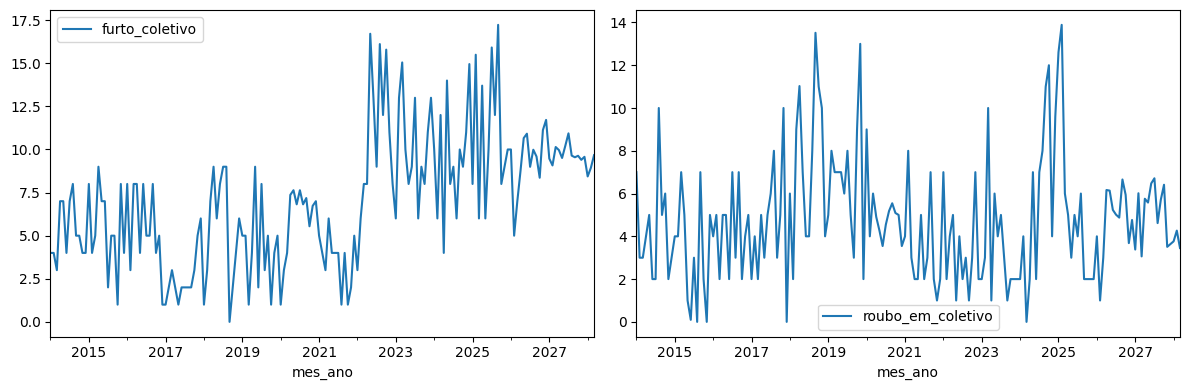

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_final[df_final["cisp"]==24].plot(x="mes_ano", y="furto_coletivo", ax=axes[0])
df_final[df_final["cisp"]==24].plot(x="mes_ano", y="roubo_em_coletivo", ax=axes[1])
plt.tight_layout()
#plt.show()


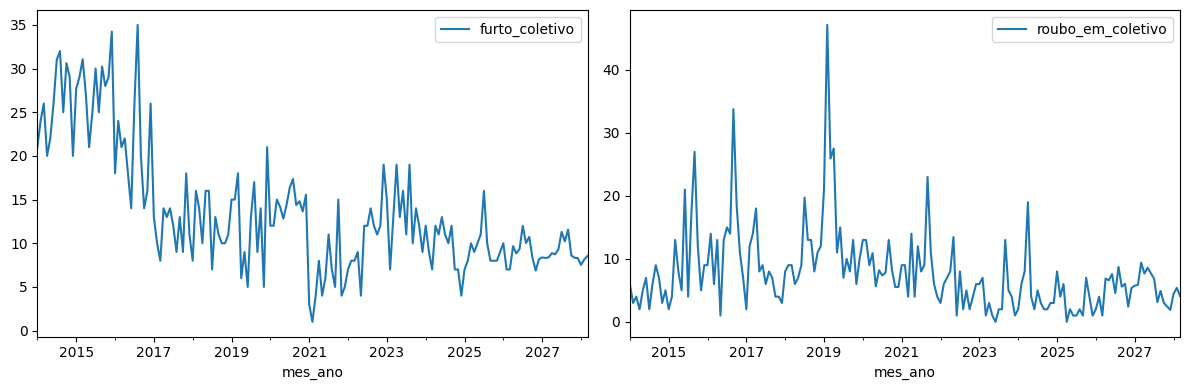

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_final[df_final["cisp"]==5].plot(x="mes_ano", y="furto_coletivo", ax=axes[0])
df_final[df_final["cisp"]==5].plot(x="mes_ano", y="roubo_em_coletivo", ax=axes[1])
plt.tight_layout()

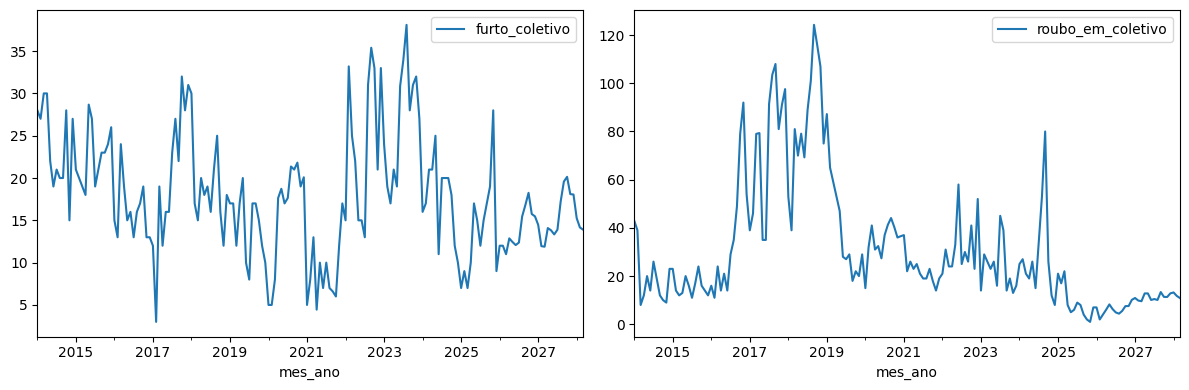

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_final[df_final["cisp"]==17].plot(x="mes_ano", y="furto_coletivo", ax=axes[0])
df_final[df_final["cisp"]==17].plot(x="mes_ano", y="roubo_em_coletivo", ax=axes[1])
plt.tight_layout()

Perfeito! Os dois modelos aparentam estar funcionado razoavelmente. Posso agora salvar esse dataset final, que será enviado para a solução!

In [26]:
df_final.to_pickle("../datasets/dados_finais")